In [2]:
!pip install s3fs

/bin/bash: switchml: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `switchml'
/bin/bash: module: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `module'


In [3]:
!pip install matplotlib seaborn scikit-learn

/bin/bash: switchml: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `switchml'
/bin/bash: module: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `module'
  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-p

In [4]:
!pip uninstall -y numpy pandas pyarrow
!pip install numpy==1.26.4 pandas==2.1.4 pyarrow==14.0.2

/bin/bash: switchml: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `switchml'
/bin/bash: module: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `module'
Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
/bin/bash: switchml: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `switchml'
/bin/bash: module: line 1: syntax error: unexpected end of file
/bin/bash: error importing function definition for `module'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 213.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 245.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 225.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [p

In [8]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import s3fs

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [7]:
# Load Sample Dataset (Parquet)

df = pd.read_parquet("s3://"your-bucket"/ml/sample_parquet/")
print(df.shape)
df.head()

(8274232, 12)


,year,approved_flag,income_000s,loan_amount_000s,tract_minority_pct,tract_income_pct,loan_type,loan_purpose,occupancy_type,lien_status,channel_label,purchaser_label
0,2023,0,84.0,25000.0,60.52,119.96,1,4,2,2,Direct,Retained
1,2023,1,105.0,35000.0,8.75,182.83,1,2,1,2,Direct,Retained
2,2023,1,206.0,305000.0,65.21,117.65,1,2,1,2,Direct,Retained
3,2023,0,106.0,105000.0,17.14,134.88,1,4,1,2,Direct,Retained
4,2023,0,87.0,205000.0,10.76,140.10,1,2,1,2,Direct,Retained


In [9]:
# Inspect Schema
print(df.dtypes)

year                    int32
approved_flag           int32
income_000s           float64
loan_amount_000s      float64
tract_minority_pct    float64
tract_income_pct      float64
loan_type               int32
loan_purpose            int32
occupancy_type          int32
lien_status             int32
channel_label          object
purchaser_label        object
dtype: object


In [10]:
# Compute Correct Loan-to-Income Ratio
# LTI = loan_amount / (income_000s * 1000)
# Disable scientific notation globally 
pd.set_option("display.float_format", "{:.6f}".format)

df["correct_lti"] = df["loan_amount_000s"] / (df["income_000s"] * 1000)

df["correct_lti"].describe(percentiles=[0.5, 0.9, 0.99])

# The extremely high LTI outlier values affect evaluation 
# more than the extremely low outlier values.
# Hence, only extermely high values will be removed.

count   8274232.000000
mean          2.935405
std          27.239792
min           0.000020
50%           2.415730
90%           4.708738
99%           8.690476
max       65811.000000
Name: correct_lti, dtype: float64

In [11]:
# Remove extremely high outlier LTI values

df = df[df["correct_lti"] < 20]
print("Shape after filtering:", df.shape)

Shape after filtering: (8245856, 13)


In [12]:
# Log Transform Income & Loan Amount

import numpy as np

df["log_income"] = np.log1p(df["income_000s"])
df["log_loan"] = np.log1p(df["loan_amount_000s"])

In [13]:
# Separate Features and Target

y = df["approved_flag"]

# Make sure target is 1D series
y = df["approved_flag"].astype(int)

X = df.drop(columns=[
    "approved_flag",
    "income_000s",
    "loan_amount_000s",
    "year"   # IMPORTANT: exclude year
])

In [14]:
# One-Hot Encode Categorical Variables

X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (8245856, 17)


In [15]:
# Standardize Features (Required for SGD Classifier)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# 80/20 Training and Test Data Split (After Scaling)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Train Logistic Regression via SGD

from sklearn.linear_model import SGDClassifier

model = SGDClassifier(
    loss="log_loss",
    max_iter=20,
    tol=1e-3,
    verbose=1,
    n_jobs=-1
)

model.fit(X_train, y_train)

-- Epoch 1
Norm: 3.83, NNZs: 17, Bias: 1.444176, T: 6596684, Avg. loss: 0.346904
Total training time: 1.51 seconds.
-- Epoch 2
Norm: 3.84, NNZs: 17, Bias: 1.466974, T: 13193368, Avg. loss: 0.336172
Total training time: 3.02 seconds.
-- Epoch 3
Norm: 3.79, NNZs: 17, Bias: 1.500456, T: 19790052, Avg. loss: 0.335992
Total training time: 4.53 seconds.
-- Epoch 4
Norm: 3.77, NNZs: 17, Bias: 1.481631, T: 26386736, Avg. loss: 0.335926
Total training time: 6.05 seconds.
-- Epoch 5
Norm: 3.80, NNZs: 17, Bias: 1.470278, T: 32983420, Avg. loss: 0.335885
Total training time: 7.57 seconds.
-- Epoch 6
Norm: 3.78, NNZs: 17, Bias: 1.480948, T: 39580104, Avg. loss: 0.335860
Total training time: 9.08 seconds.
-- Epoch 7
Norm: 3.81, NNZs: 17, Bias: 1.480026, T: 46176788, Avg. loss: 0.335846
Total training time: 10.59 seconds.
Convergence after 7 epochs took 10.59 seconds


,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,20
,tol,0.001
,shuffle,True
,verbose,1
,epsilon,0.1
,n_jobs,-1


In [18]:
# Evaluation

from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# We get accuracy of 81% and ROC-AUC of 91%. We checked earlier in AWS Athena 
# what the Class-Balance is. It was moderately Balanced.
# Approved (1): ~55.5M → 57.18%
# Not approved (0): ~41.6M → 42.81%
# Hence, this Accuracy metrics reflects genuine predictive power.
# This model can distinguish approved vs denied loans well.

Accuracy: 0.8183640032695195
ROC-AUC: 0.913076055025291


In [19]:
# Check Classs Distribution

y.value_counts(normalize=True)

approved_flag
1   0.615830
0   0.384170
Name: proportion, dtype: float64

In [20]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

# Confusion Matrix :-
# [[ TN   FP ]
# [ FN   TP ]]

array([[545205,  89322],
       [210227, 804418]])

In [21]:
"""
Confusion Matrix Counts
TN = 547,898
FP = 85,851
FN = 212,356
TP = 802,934
"""

'\nConfusion Matrix Counts\nTN = 547,898\nFP = 85,851\nFN = 212,356\nTP = 802,934\n'

In [22]:
# Full Classification Report

from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.913076055025291

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.86      0.78    634527
           1       0.90      0.79      0.84   1014645

    accuracy                           0.82   1649172
   macro avg       0.81      0.83      0.81   1649172
weighted avg       0.83      0.82      0.82   1649172



In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision (Approved):", precision) 
print("Recall (Approved):", recall)
print("F1 Score (Approved):", f1)

Precision (Approved): 0.9000581824691745
Recall (Approved): 0.7928073365561354
F1 Score (Approved): 0.8430353414012371


In [24]:
# Recall for Denied Loans
recall_denied = recall_score(y_test, y_pred, pos_label=0)

print("Recall (Denied Loans):", recall_denied)

Recall (Denied Loans): 0.8592305764766511


In [25]:
# ============================================================
# MODEL PERFORMANCE INSIGHTS
# ============================================================

# ROC-AUC = 0.913
# The model demonstrates very strong discriminatory power.
# A ROC above 0.90 indicates excellent separability between
# approved and denied mortgage applications.

# Accuracy = 81.9%
# Overall prediction accuracy is high and meaningful,
# given that the dataset is only moderately imbalanced
# (61.6% approved vs 38.4% denied).

# Precision (Approved) = 90.3%
# When the model predicts approval, it is correct over 90% of the time.
# This suggests low false approval risk.

# Recall (Approved) = 79.1%
# The model correctly captures ~79% of all approved loans.
# Some approvals are misclassified as denials (false negatives).

# Recall (Denied) = 86.5%
# The model correctly identifies 86.5% of denied applications,
# demonstrating strong denial detection capability.

# F1 Score (Approved) = 0.84
# Indicates strong balance between precision and recall.

In [26]:
# To find positive drivers of approval of loans

import pandas as pd

coefficients = pd.Series(model.coef_[0], index=X.columns)
coefficients.sort_values().tail(15)

loan_type                     -0.283343
correct_lti                   -0.257184
tract_minority_pct            -0.136678
loan_purpose                  -0.115614
channel_label_Direct          -0.110809
purchaser_label_Freddie Mac   -0.054722
occupancy_type                -0.025144
purchaser_label_Private        0.092120
log_income                     0.095982
log_loan                       0.116304
channel_label_Other            0.116661
lien_status                    0.128762
tract_income_pct               0.174459
purchaser_label_Ginnie Mae     0.232814
purchaser_label_Other          0.370715
dtype: float64

In [27]:
# ============================================================
# POSITIVE DRIVERS OF APPROVAL
# ============================================================

# purchaser_label_Other, purchaser_label_Ginnie Mae
# Loans intended for secondary market purchase (especially
# government-backed channels) show higher approval likelihood.

# tract_income_pct
# Higher-income census tracts are associated with higher approval probability.

# lien_status
# Certain lien structures positively influence underwriting outcomes.

# log_income
# Higher borrower income strongly increases approval probability.

# log_loan
# Larger loan sizes (controlling for income) correlate with approval,
# potentially reflecting stronger borrower profiles or prime lending segments.

In [28]:
# To find negative drivers of approval of loans

coefficients.sort_values().head(15)

purchaser_label_Retained      -2.855319
channel_label_Correspondent   -2.419915
loan_type                     -0.283343
correct_lti                   -0.257184
tract_minority_pct            -0.136678
loan_purpose                  -0.115614
channel_label_Direct          -0.110809
purchaser_label_Freddie Mac   -0.054722
occupancy_type                -0.025144
purchaser_label_Private        0.092120
log_income                     0.095982
log_loan                       0.116304
channel_label_Other            0.116661
lien_status                    0.128762
tract_income_pct               0.174459
dtype: float64

In [29]:
# ============================================================
# NEGATIVE DRIVERS OF APPROVAL
# ============================================================

# purchaser_label_Retained
# Loans retained on balance sheet show lower approval probability,
# possibly reflecting riskier underwriting segments.

# channel_label_Correspondent
# Correspondent channel loans appear less likely to be approved
# relative to baseline channel.

# correct_lti
# Higher loan-to-income ratio reduces approval probability,
# confirming leverage sensitivity in underwriting.

# loan_type
# Certain loan types are associated with lower approval rates.

# tract_minority_pct
# Higher minority population percentage tracts show lower
# approval probability, potentially reflecting structural
# credit distribution patterns.

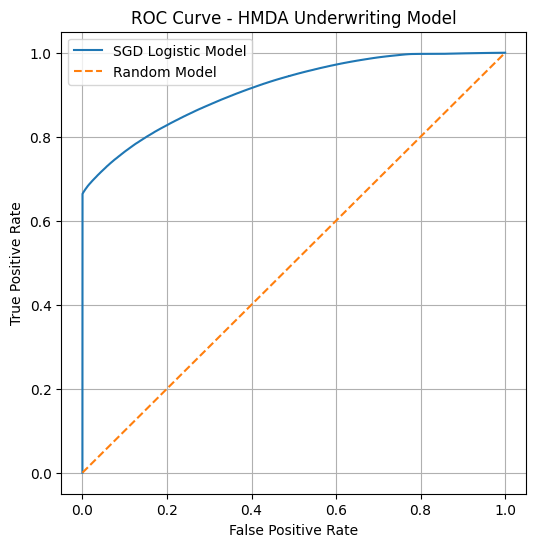

In [30]:
# ============================================================
# ROC Curve Plot
# ============================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="SGD Logistic Model")
plt.plot([0,1], [0,1], linestyle="--", label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HMDA Underwriting Model")
plt.legend()
plt.grid()
plt.show()

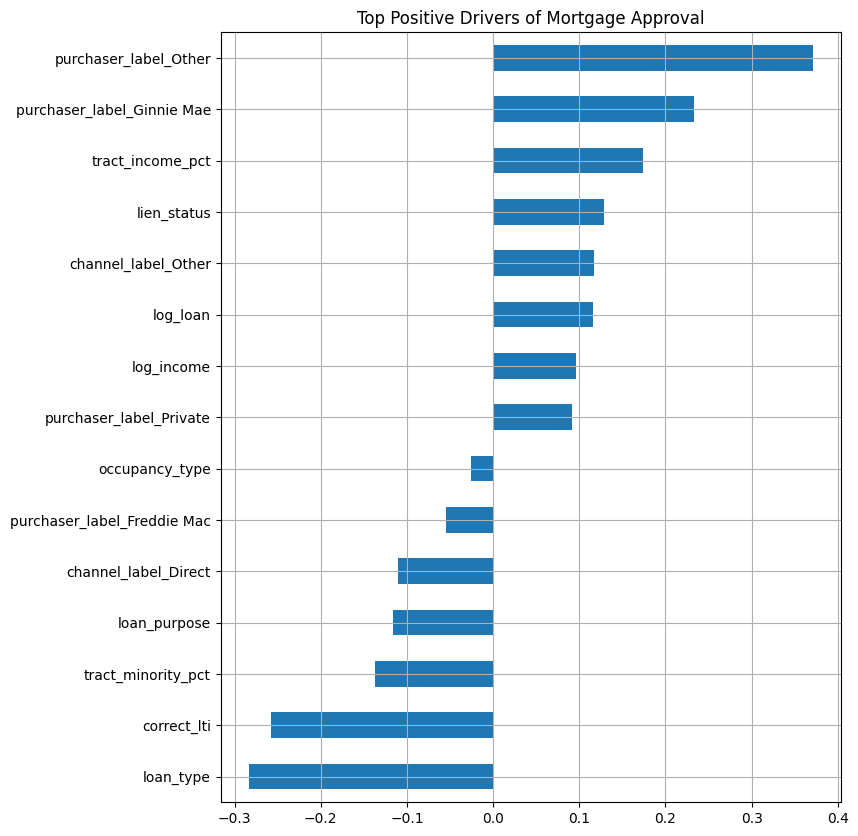

In [31]:
# Top 15 Feature Coefficients for Positive Drivers

importance = pd.Series(model.coef_[0], index=X.columns)
importance_sorted = importance.sort_values()

plt.figure(figsize=(8,10))
importance_sorted.tail(15).plot(kind="barh")
plt.title("Top Positive Drivers of Mortgage Approval")
plt.grid()
plt.show()

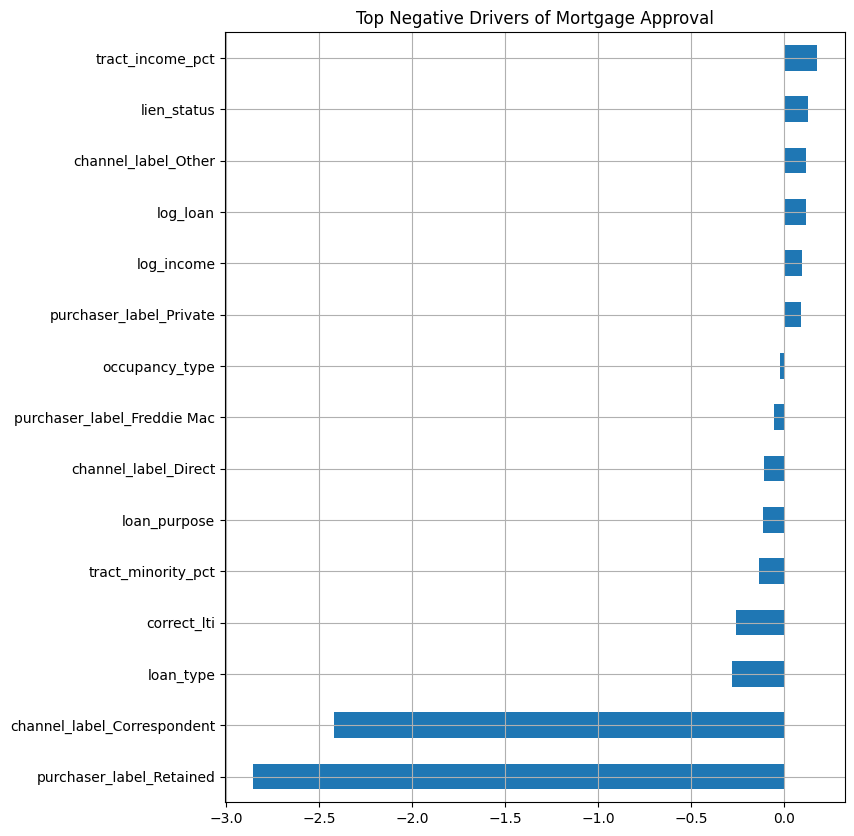

In [32]:
# Top 15 Feature Coefficients for Negative Drivers

plt.figure(figsize=(8,10))
importance_sorted.head(15).plot(kind="barh")
plt.title("Top Negative Drivers of Mortgage Approval")
plt.grid()
plt.show()

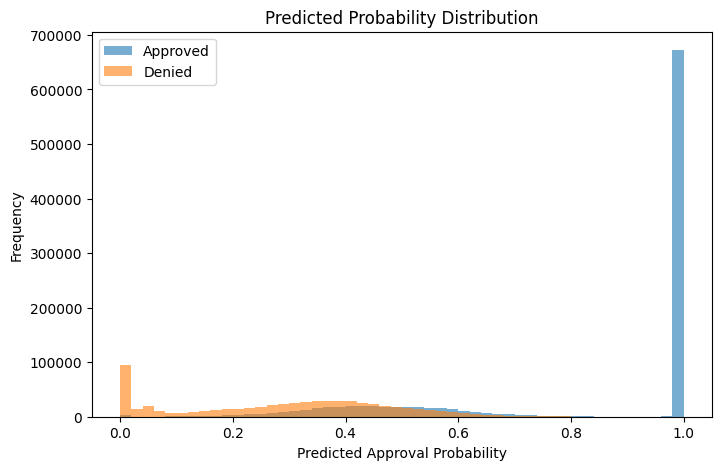

In [33]:
# ============================================================
# Probability Distribution

plt.figure(figsize=(8,5))
plt.hist(y_prob[y_test==1], bins=50, alpha=0.6, label="Approved")
plt.hist(y_prob[y_test==0], bins=50, alpha=0.6, label="Denied")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Approval Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

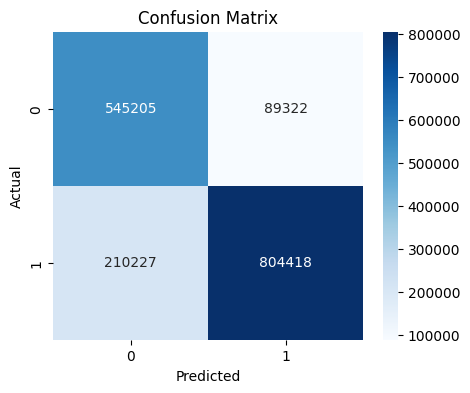

In [34]:
# Confusion Matrix Heatmap

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
# MODEL MONITORING

In [36]:
# Add year back into modeling dataframe

df_monitor = df.copy()

In [37]:
# Compute ROC by Year

from sklearn.metrics import roc_auc_score

roc_by_year = []

for yr in df_monitor["year"].unique():
    mask = df_monitor["year"] == yr
    
    X_year = X_scaled[mask]
    y_year = y[mask]
    
    y_prob_year = model.predict_proba(X_year)[:, 1]
    roc = roc_auc_score(y_year, y_prob_year)
    
    roc_by_year.append({"year": yr, "roc_auc": roc})

import pandas as pd
roc_by_year = pd.DataFrame(roc_by_year).sort_values("year")

roc_by_year

,year,roc_auc
1,2019,0.915056
4,2020,0.928263
3,2021,0.922038
2,2022,0.894062
0,2023,0.875113


In [38]:
# roc_by_year.to_csv("roc_by_year.csv", index=False)

In [39]:
# APPROVAL RATE DRIFT

approval_drift = df_monitor.groupby("year")["approved_flag"].mean().reset_index()
approval_drift.columns = ["year", "actual_approval_rate"]

approval_drift

,year,actual_approval_rate
0,2019,0.596067
1,2020,0.633967
2,2021,0.646638
3,2022,0.591514
4,2023,0.572931


In [40]:
# approval_drift.to_csv("approval_drift.csv", index=False)

In [41]:
# Average LTI by Year

lti_drift = df_monitor.groupby("year")["correct_lti"].mean().reset_index()

# lti_drift.to_csv("lti_drift.csv", index=False)

lti_drift

,year,correct_lti
0,2019,2.518397
1,2020,2.640078
2,2021,2.792463
3,2022,2.629009
4,2023,2.266681


In [42]:
df_monitor["predicted_prob"] = model.predict_proba(X_scaled)[:,1]

predicted_rate = df_monitor.groupby("year")["predicted_prob"].mean().reset_index()
predicted_rate.columns = ["year", "predicted_approval_rate"]

predicted_rate.to_csv("predicted_approval_rate.csv", index=False)

In [43]:
predicted_rate

,year,predicted_approval_rate
0,2019,0.584832
1,2020,0.635876
2,2021,0.645108
3,2022,0.587728
4,2023,0.585758
